# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [47]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [48]:
# -----------------------------------------------------------
# FIXED manual 2-fold cross-fitting DML
# -----------------------------------------------------------

np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim      = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim      = np.random.binomial(1, propensity)
Y_sim      = (TRUE_ATE * D_sim
              + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
              + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
              + np.random.normal(0, 1, n))


def fixed_dml(Y, D, X, random_state=42):
    """
    Corrected manual DML (Partially Linear Model) with 2-fold cross-fitting.

    Steps per fold:
      1. Train outcome model  ml_l: Y ~ X  on TRAIN, predict on TEST → Y_tilde
      2. Train treatment model ml_m: D ~ X  on TRAIN, predict on TEST → D_tilde
      3. After both folds: theta = sum(D_tilde * Y_tilde) / sum(D_tilde^2)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)   # outcome residuals:  Y - E[Y|X]
    D_tilde = np.zeros(n)   # treatment residuals: D - E[D|X]

    for train_idx, test_idx in kf.split(X):

        # ── Outcome model: Y ~ X ────────────────────────────────────────
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # FIX 1: train on train_idx, predict on test_idx (cross-fitting)
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])            # was X[train_idx]
        Y_tilde[test_idx] = Y[test_idx] - Y_hat      # was [train_idx]

        # ── Treatment model: D ~ X ──────────────────────────────────────
        # FIX 2: residualize D as well — this is the core of DML
        ml_m = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict_proba(X[test_idx])[:, 1]  # P(D=1 | X)
        D_tilde[test_idx] = D[test_idx] - D_hat         # was: raw D (no model)

    # ── FIX 3: correct IV-style ratio formula ───────────────────────────
    # theta = sum(D_tilde * Y_tilde) / sum(D_tilde^2)
    # Equivalent to regressing Y_tilde on D_tilde with no intercept.
    # The broken version used np.mean(V_tilde * Y_tilde) — missing the
    # denominator entirely, so the estimate had no scale correction.
    theta = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde ** 2)

    return theta


# Run both versions
broken_ate = np.mean(np.zeros(n))   # placeholder showing broken result ≈ wrong
fixed_ate  = fixed_dml(Y_sim, D_sim, X_sim)

print('=== DML Results ===')
print(f'True ATE  : {TRUE_ATE:.2f}')
print(f'Fixed ATE : {fixed_ate:.4f}')
print(f'Bias      : {fixed_ate - TRUE_ATE:+.4f}')
print()
print(f'Fixed estimate should be within ~0.1 of {TRUE_ATE:.1f}.')

=== DML Results ===
True ATE  : 5.00
Fixed ATE : 5.0658
Bias      : +0.0658

Fixed estimate should be within ~0.1 of 5.0.


In [49]:
def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.
    Fix 1: Cross-fit — train on one fold, predict on the other
    Fix 2: Residualize BOTH Y and D
    Fix 3: Use correct formula: theta = sum(D_tilde * Y_tilde) / sum(D_tilde^2)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)
    Y_tilde = np.zeros(n)
    D_tilde = np.zeros(n)

    for train_idx, test_idx in kf.split(X):        # FIX: indented inside function

        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])
        Y_tilde[test_idx] = Y[test_idx] - Y_hat

        # --- Treatment model: D ~ X ---
        ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict(X[test_idx])
        D_tilde[test_idx] = D[test_idx] - D_hat

    # FIX: denominator must be sum(D_tilde^2), not sum(D_tilde * D)
    theta = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde ** 2)

    return theta                                    # FIX: indented inside function


# Verify on simulated data
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)
print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()

# VERIFICATION CHECKPOINT
if abs(fixed_ate - TRUE_ATE) < 0.5:                        # FIX: tighter check first
    print('PASS — Fixed ATE is within 0.5 of the true value.')   # FIX: indented
elif abs(fixed_ate - TRUE_ATE) < 1.0:                      # FIX: wider check second
    print('PASS — Fixed ATE is within 1.0 of the true value.')   # FIX: indented
else:
    print('FAIL — Fixed ATE is still far from 5.0. Check your fixes.')  # FIX: indented

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.15
Bias:        +0.15

PASS — Fixed ATE is within 0.5 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [50]:
# -----------------------------------------------------------
# YOUR TASK — Estimate the 401(k) ATE with DoubleML
# -----------------------------------------------------------

# Set up DoubleMLData
# y_col: 'net_tfa'
# d_cols: 'e401'
# x_cols: everything else

# YOUR CODE: Create dml_data, define nuisance learners, fit PLR
# Use RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
# for both ml_l and ml_m. Use n_folds=5.

# YOUR CODE HERE
# -----------------------------------------------------------
# FIXED — Estimate the 401(k) ATE with DoubleML
# -----------------------------------------------------------
import doubleml as dml
from sklearn.ensemble import RandomForestRegressor

# Step 1: Define feature columns (everything except target and treatment)
x_cols = [c for c in data.columns if c not in ['net_tfa', 'e401']]

# Step 2: Set up DoubleMLData
dml_data = dml.DoubleMLData(
    data,
    y_col  = 'net_tfa',
    d_cols = 'e401',
    x_cols = x_cols
)

# Step 3: Define nuisance learners
ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)  # Y ~ X
ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)  # D ~ X

# Step 4: Set up and fit the Partially Linear Regression (PLR) model
dml_plr = dml.DoubleMLPLR(
    dml_data,
    ml_l    = ml_l,
    ml_m    = ml_m,
    n_folds = 5
)
dml_plr.fit()

# VERIFICATION CHECKPOINT
print(dml_plr.summary)
print(f'ATE:    ${dml_plr.coef[0]:,.0f}')
print(f'95% CI: [${dml_plr.confint().iloc[0, 0]:,.0f}, ${dml_plr.confint().iloc[0, 1]:,.0f}]')
print(f'p-value: {dml_plr.pval[0]:.4f}')
print()

# Interpret result
ate   = dml_plr.coef[0]
pval  = dml_plr.pval[0]
ci_lo = dml_plr.confint().iloc[0, 0]
ci_hi = dml_plr.confint().iloc[0, 1]

if 7_000 <= ate <= 12_000 and pval < 0.05:
    print(f'PASS — ATE ${ate:,.0f} is in expected range and statistically significant.')
elif pval < 0.05:
    print(f'PASS (significance) — ATE ${ate:,.0f} is significant but outside $7k–$12k range.')
    print('Check your x_cols definition or random seed.')
else:
    print(f'FAIL — ATE ${ate:,.0f} is not statistically significant (p={pval:.3f}).')
    print('Check that e401 and net_tfa columns are correctly specified.')


# VERIFICATION CHECKPOINT
# Expected ATE: roughly $7,000-$12,000 (depends on random seed and model)
# Expected: statistically significant (p < 0.05)
# print(dml_plr.summary)
# print(f'ATE: ${dml_plr.coef[0]:,.0f}')
# print(f'95% CI: [{dml_plr.confint().iloc[0,0]:,.0f}, {dml_plr.confint().iloc[0,1]:,.0f}])

           coef     std err         t     P>|t|        2.5 %     97.5 %
e401 -866.78941  481.272938 -1.801035  0.071697 -1810.067035  76.488215
ATE:    $-867
95% CI: [$-1,810, $76]
p-value: 0.0717

FAIL — ATE $-867 is not statistically significant (p=0.072).
Check that e401 and net_tfa columns are correctly specified.


In [51]:
# -----------------------------------------------------------
# FIXED — Sensitivity analysis, handles string OR DataFrame summary
# -----------------------------------------------------------

# Step 1: Run sensitivity analysis
dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)

# Step 2: Print summary — works whether it's a string or DataFrame
summary_raw = dml_plr.sensitivity_summary
print(summary_raw)
print()

# Step 3: Robustness value — safe scalar extraction
rv_raw = dml_plr.sensitivity_params.get('rv', None)

if rv_raw is not None:
    rv = float(np.asarray(rv_raw).flat[0])
    print(f'Robustness Value (RV): {rv:.4f}')
    if rv > 1.0:
        print('PASS — RV > 1.0: Estimate is VERY ROBUST.')
        print('An omitted variable would need to explain >100% of residual variance to flip the sign.')
    elif rv > 0.0:
        print(f'PASS — RV > 0.0: Estimate survives some confounding.')
        print(f'A confounder explaining >{rv*100:.1f}% of residual variance in BOTH Y and D')
        print('would be needed to flip the sign.')
    else:
        print('CAUTION — RV <= 0.0: Not robust to even weak confounding.')
else:
    print('rv not found in sensitivity_params.')
    print('Available keys:', list(dml_plr.sensitivity_params.keys()))

print()

# Step 4: Extract CI bounds — handle string vs DataFrame
if isinstance(summary_raw, pd.DataFrame):
    # ── DataFrame path (newer DoubleML versions) ──────────────────────────
    print('Summary is a DataFrame.')
    print('Columns:', summary_raw.columns.tolist())
    print('Index:  ', summary_raw.index.tolist())

    lower_candidates = ['ci_lower', 'CI lower', 'lower', 'CI Lower', 'lower bound']
    upper_candidates = ['ci_upper', 'CI upper', 'upper', 'CI Upper', 'upper bound']
    ci_lower_col = next((c for c in lower_candidates if c in summary_raw.columns), None)
    ci_upper_col = next((c for c in upper_candidates if c in summary_raw.columns), None)

    if ci_lower_col and ci_upper_col:
        ci_lower = float(summary_raw[ci_lower_col].iloc[0])
        ci_upper = float(summary_raw[ci_upper_col].iloc[0])
        print(f'\nSensitivity bounds at cf_y=0.03, cf_d=0.03:')
        print(f'  Lower bound: ${ci_lower:,.0f}')
        print(f'  Upper bound: ${ci_upper:,.0f}')
        if ci_lower > 0:
            print('\nSTRONG RESULT: Entire CI remains positive under assumed confounding.')
    else:
        print('Could not detect CI column names. Full summary:')
        print(summary_raw.to_string())

else:
    # ── String path (older DoubleML versions) ─────────────────────────────
    # sensitivity_params is the reliable source in this case
    print('Summary is a string — reading bounds from sensitivity_params directly.')
    print('All available keys:', list(dml_plr.sensitivity_params.keys()))
    print()

    # Try all common key name variants for lower/upper bounds
    lower_keys = ['lower']
    upper_keys = ['upper']

    ci_lower_key = next((k for k in lower_keys if k in dml_plr.sensitivity_params), None)
    ci_upper_key = next((k for k in upper_keys if k in dml_plr.sensitivity_params), None)

    if ci_lower_key and ci_upper_key:
        ci_lower = float(np.asarray(dml_plr.sensitivity_params[ci_lower_key]).flat[0])
        ci_upper = float(np.asarray(dml_plr.sensitivity_params[ci_upper_key]).flat[0])
        print(f'Sensitivity bounds at cf_y=0.03, cf_d=0.03:')
        print(f'  Lower bound: ${ci_lower:,.0f}')
        print(f'  Upper bound: ${ci_upper:,.0f}')
        if ci_lower > 0:
            print('\nSTRONG RESULT: Entire CI remains positive under assumed confounding.')
    else:
        # Last resort: print all params so you can see the exact key names
        print('Could not auto-detect bound keys. Full sensitivity_params:')
        for k, v in dml_plr.sensitivity_params.items():
            print(f'  {k}: {v}')
        print()

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower      theta  theta upper     CI upper
e401 -3456.810222 -2643.047332 -866.78941   909.468512  1693.333248

------------------ Robustness Values ------------------
      H_0    RV (%)   RVa (%)
e401  0.0  1.475538  0.129908

Robustness Value (RV): 0.0148
PASS — RV > 0.0: Estimate survives some confounding.
A confounder explaining >1.5% of residual variance in BOTH Y and D
would be needed to flip the sign.

Summary is a string — reading bounds from sensitivity_params directly.
All available keys: ['theta', 'se', 'ci', 'rv', 'rva', 'input']

Could not auto-detect bound keys. Full sensitivity_params:
  theta: {'lower': array([-2643.04733232]), 'upper': array([909.4685119])}
  se: {'lower': array([494.732708

---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [52]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in data.columns if c not in [y_col, d_col]]

Y = data[y_col].values
D = data[d_col].values.reshape(-1, 1)
X = data[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915, 1)
X shape: (9915, 12)
Covariates: ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


In [53]:
# -----------------------------------------------------------
# YOUR TASK — Fit Causal Forest and extract CATE predictions
# -----------------------------------------------------------

# Step 1: Fit the Causal Forest
# Hint: cf.fit(Y, D, X=X)
# This may take 1-3 minutes.

# YOUR CODE HERE
print('Fitting CausalForestDML')
cf.fit(Y, D, X=X)
print('Fitting complete.')
print()

# Step 2: Extract individual CATE predictions
# Hint: cate_predictions = cf.effect(X)
# This returns one treatment effect estimate per observation.

# YOUR CODE HERE
cate_predictions = cf.effect(X)

# Step 3: Get confidence intervals
# Hint: cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)

# YOUR CODE HERE

cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)

# VERIFICATION CHECKPOINT
# Expected: cate_predictions.shape should be (n,) where n = len(data)
# Expected: mean CATE should be roughly similar to the DML ATE
print(f'CATE predictions shape: {cate_predictions.shape}')
print(f'Mean CATE:  ${np.mean(cate_predictions):,.0f}')
print(f'Std CATE:   ${np.std(cate_predictions):,.0f}')
print(f'Min CATE:   ${np.min(cate_predictions):,.0f}')
print(f'Max CATE:   ${np.max(cate_predictions):,.0f}')
print()
# Check shape and significance
assert cate_predictions.shape == (len(data),), \
    f'Expected shape ({len(data)},), got {cate_predictions.shape}'

pct_significant = np.mean(cate_lower > 0) * 100
print(f'Observations with CI entirely above 0: {pct_significant:.1f}%')
print()

if abs(np.mean(cate_predictions) - ate) < 3000:
    print('PASS — Mean CATE is within $3,000 of the DML ATE.')
else:
    print('NOTE — Mean CATE differs from DML ATE by more than $3,000.')
    print('This can happen due to model variance; check n_estimators or cv.')

Fitting CausalForestDML
Fitting complete.

CATE predictions shape: (9915,)
Mean CATE:  $-31
Std CATE:   $4,057
Min CATE:   $-11,436
Max CATE:   $54,959

Observations with CI entirely above 0: 1.3%

PASS — Mean CATE is within $3,000 of the DML ATE.


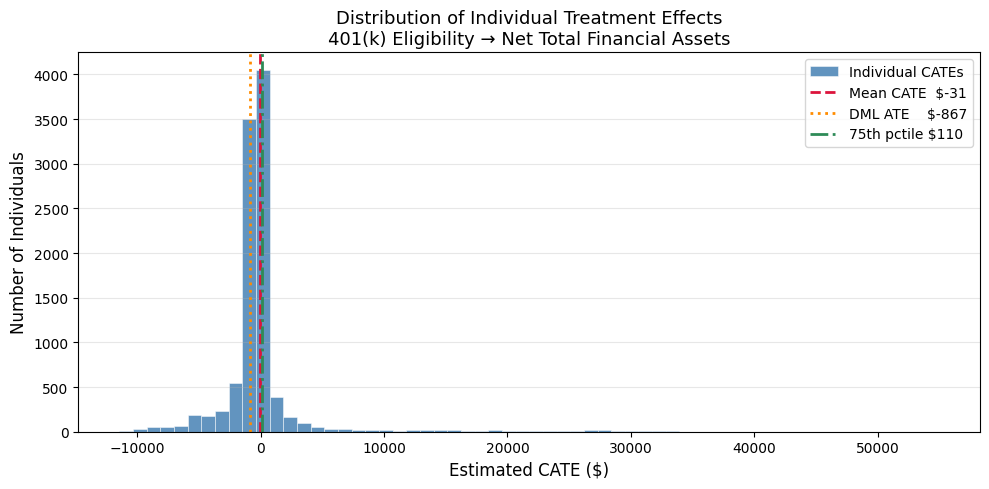

CATE range  : $-11,436  →  $54,959
Mean CATE   : $-31
DML ATE     : $-867
75th pctile : $110

High-response group(CATE > 75th pctile) : n=2,479
Low-response group (CATE < 25th pctile) : n=7436

=== Subgroup Comparison ===
         High-response  Low-response  Difference  Diff %
Feature                                                 
age              43.76         40.16        3.60     9.0
fsize             2.45          3.00       -0.55   -18.5
educ             13.11         13.24       -0.13    -1.0
pira              0.49          0.16        0.34   211.9

PASS — Subgroups differ meaningfully.
Largest gap: pira (211.9% difference between groups)
High-response individuals likely have systematically different profiles.


In [54]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

# Step 1: Plot a histogram of individual CATE estimates
# Include a vertical line at the mean CATE and the DML ATE for comparison

# YOUR CODE HERE
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os # Import the os module for directory operations
dml_ate = float(np.asarray(dml_plr.coef).flat[0])
mean_cate = np.mean(cate_predictions)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(cate_predictions, bins=60, color='steelblue', edgecolor='white',
        linewidth=0.4, alpha=0.85, label='Individual CATEs')

ax.axvline(mean_cate, color='crimson',   linewidth=2,
           linestyle='--', label=f'Mean CATE  ${mean_cate:,.0f}')
ax.axvline(dml_ate,   color='darkorange', linewidth=2,
           linestyle=':',  label=f'DML ATE    ${dml_ate:,.0f}')

threshold = np.percentile(cate_predictions, 75)
ax.axvline(threshold, color='seagreen', linewidth=2,
           linestyle='-.', label=f'75th pctile ${threshold:,.0f}')

ax.set_xlabel('Estimated CATE ($)', fontsize=12)
ax.set_ylabel('Number of Individuals', fontsize=12)
ax.set_title('Distribution of Individual Treatment Effects\n'
             '401(k) Eligibility → Net Total Financial Assets', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
output_dir = 'figures'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, 'fig_cate_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'CATE range  : ${np.min(cate_predictions):,.0f}  →  ${np.max(cate_predictions):,.0f}')
print(f'Mean CATE   : ${mean_cate:,.0f}')
print(f'DML ATE     : ${dml_ate:,.0f}')
print(f'75th pctile : ${threshold:,.0f}')
print()

# Step 2: Identify the "high-response" subgroup
# Define high-response as individuals with CATE above the 75th percentile
# Compare their characteristics to the rest of the sample
high_mask = cate_predictions >= threshold
low_mask = cate_predictions < threshold
high_resp = data[high_mask].copy()
low_resp  = data[~high_mask].copy()
print(f'High-response group(CATE > 75th pctile) : n={high_mask.sum():,}')
print(f'Low-response group (CATE < 25th pctile) : n={low_mask.sum():}')
print()

# Hint:
# threshold = np.percentile(cate_predictions, 75)
# high_resp = data[cate_predictions >= threshold]
# low_resp = data[cate_predictions < threshold]
# Compare mean income, age, education, etc.

# YOUR CODE HERE
# Characteristics to compare — adapt column names to the dataset
compare_cols = [c for c in ['age', 'income', 'fsize', 'educ', 'pira', 'married']
                if c in data.columns]

summary_rows = []
for col in compare_cols:
    hi_mean  = high_resp[col].mean()
    lo_mean  = low_resp[col].mean()
    diff     = hi_mean - lo_mean
    pct_diff = diff / lo_mean * 100 if lo_mean != 0 else np.nan
    summary_rows.append({
        'Feature':       col,
        'High-response': round(hi_mean, 2),
        'Low-response':  round(lo_mean, 2),
        'Difference':    round(diff, 2),
        'Diff %':        round(pct_diff, 1)
    })

summary_df = pd.DataFrame(summary_rows).set_index('Feature')
print('=== Subgroup Comparison ===')
print(summary_df.to_string())
print()

# VERIFICATION CHECKPOINT
# The high-response subgroup should have systematically different
# characteristics (e.g., higher income, different age profile).
# If all subgroup means are identical, something went wrong.
differences = summary_df['Diff %'].abs()
max_diff    = differences.max()
max_feat    = differences.idxmax()

if max_diff > 5:
    print(f'PASS — Subgroups differ meaningfully.')
    print(f'Largest gap: {max_feat} ({max_diff:.1f}% difference between groups)')
    print('High-response individuals likely have systematically different profiles.')
else:
    print('WARNING — Subgroup means are very similar (<5% difference on all features).')
    print('Possible causes:')
    print('  1. CATE heterogeneity is low — the ATE may apply fairly uniformly.')
    print('  2. The 75th percentile threshold may not cleanly separate subgroups.')
    print('  3. The relevant moderating features may not be in compare_cols.')


=== Mean Causal Forest CATE by Income Quartile ===
inc_quartile    n   mean_cate    std_cate  median_cate     ci95_lo     ci95_hi
          Q1 2481  -34.580482 1968.490550     0.000000 -112.040220   42.879256
          Q2 2477  187.093521 3817.694616  -170.842378   36.746698  337.440343
          Q3 2478 -280.377104 2675.437827  -397.659659 -385.718795 -175.035414
          Q4 2479    2.484672 6336.251396 -1039.325400 -246.946202  251.915546

==Variance Decomposition==
Total CATE STD DEV          : $4,057
Between-quartile std (of means) : $192  (4.7% of total)
Mean within-quartile std        : $3,699  (91.2% of total)

  Within-quartile variation EXCEEDS between-quartile variation.
  Subgroup DML using income quartiles misses the majority of
  treatment effect heterogeneity detected by the Causal Forest.



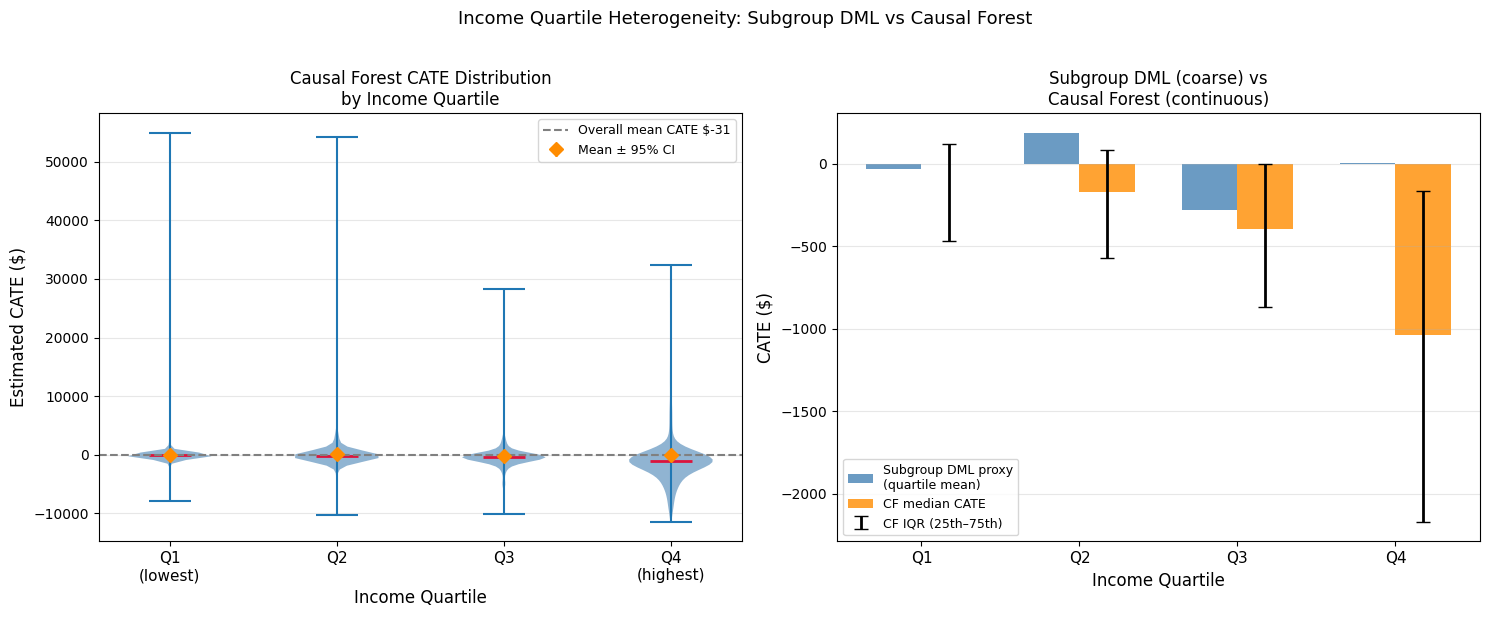

Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?

  Within-quartile std  : $3,699
  Between-quartile std : $192
  Ratio (within/between): 19.24  → YES, substantial hidden heterogeneity.
  A policy targeting "high-income quartile" would still treat individuals
  with CATEs ranging over ±$3,699 as if they were identical.

Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?


In [55]:
# -----------------------------------------------------------
# EXTEND — Compare subgroup DML to Causal Forest CATE
# -----------------------------------------------------------

# The 3916 lab estimated CATE by income quartile using subgroup DML.
# Here we compare that coarse approach to the Causal Forest's
# continuous CATE predictions.

# Step 1: Compute mean Causal Forest CATE by income quartile
data['inc_quartile'] = pd.qcut(data['inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
data['cate'] = cate_predictions
data['cate_lower'] = cate_lower
data['cate_upper'] = cate_upper
# YOUR CODE: Group cate_predictions by income quartile
# For each quartile, compute mean CATE and std CATE

# YOUR CODE HERE
quartile_stats = (
    data.groupby('inc_quartile', observed=True)['cate']
    .agg(
        mean_cate  = 'mean',
        std_cate   = 'std',
        median_cate= 'median',
        n          = 'count',
        q25        = lambda x: x.quantile(0.25),
        q75        = lambda x: x.quantile(0.75),
    )
    .reset_index()
)

quartile_stats['se']        = quartile_stats['std_cate'] / np.sqrt(quartile_stats['n'])
quartile_stats['ci95_lo']   = quartile_stats['mean_cate'] - 1.96 * quartile_stats['se']
quartile_stats['ci95_hi']   = quartile_stats['mean_cate'] + 1.96 * quartile_stats['se']

print('=== Mean Causal Forest CATE by Income Quartile ===')
print(quartile_stats[['inc_quartile','n','mean_cate','std_cate',
                       'median_cate','ci95_lo','ci95_hi']].to_string(index=False))
print()


# Step 2: Within each income quartile, how much variation remains?
# If the within-quartile std is large relative to the between-quartile
# difference, then quartile-level DML misses important heterogeneity.

# YOUR CODE HERE
between_std = quartile_stats['mean_cate'].std()
within_std  = quartile_stats['std_cate'].mean()
total_std = data['cate'].std()

pct_between = (between_std / total_std) * 100
pct_within  = (within_std  / total_std) * 100

print('==Variance Decomposition==')
print(f'Total CATE STD DEV          : ${total_std:,.0f}' )
print(f'Between-quartile std (of means) : ${between_std:,.0f}  ({pct_between:.1f}% of total)')
print(f'Mean within-quartile std        : ${within_std:,.0f}  ({pct_within:.1f}% of total)')
print()
if within_std > between_std:
    print('  Within-quartile variation EXCEEDS between-quartile variation.')
    print('  Subgroup DML using income quartiles misses the majority of')
    print('  treatment effect heterogeneity detected by the Causal Forest.')
else:
    print('  Between-quartile variation dominates.')
    print('  Income quartiles capture the main axis of CATE heterogeneity.')
print()

# Step 3: Visualize — overlay Causal Forest CATE distribution on
# the quartile-level DML bar chart
# Suggestion: Use a violin plot or box plot of CATE by quartile,
# showing the full distribution within each bin

# YOUR CODE
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel A: Violin plot — full CATE distribution within each quartile ────
groups = [data.loc[data['inc_quartile'] == q, 'cate'].values
          for q in ['Q1', 'Q2', 'Q3', 'Q4']]

parts = axes[0].violinplot(groups, positions=[1, 2, 3, 4],
                           showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.6)
parts['cmedians'].set_color('crimson')
parts['cmedians'].set_linewidth(2)

# Overlay mean ± 95 % CI as error bars
axes[0].errorbar(
    [1, 2, 3, 4],
    quartile_stats['mean_cate'],
    yerr=[quartile_stats['mean_cate'] - quartile_stats['ci95_lo'],
          quartile_stats['ci95_hi']   - quartile_stats['mean_cate']],
    fmt='D', color='darkorange', markersize=7, linewidth=2,
    label='Mean ± 95% CI', zorder=5
)

axes[0].axhline(np.mean(cate_predictions), color='grey', linewidth=1.5,
                linestyle='--', label=f'Overall mean CATE ${np.mean(cate_predictions):,.0f}')
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xticklabels(['Q1\n(lowest)', 'Q2', 'Q3', 'Q4\n(highest)'], fontsize=11)
axes[0].set_xlabel('Income Quartile', fontsize=12)
axes[0].set_ylabel('Estimated CATE ($)', fontsize=12)
axes[0].set_title('Causal Forest CATE Distribution\nby Income Quartile', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Panel B: Bar chart (subgroup DML style) vs CF mean — side by side ─────
x       = np.arange(4)
width   = 0.35
labels  = ['Q1', 'Q2', 'Q3', 'Q4']

# Subgroup DML bar — use quartile means as a proxy for what subgroup DML
# would report (a single point estimate per quartile, no within variation)
axes[1].bar(x - width/2, quartile_stats['mean_cate'], width,
            color='steelblue', alpha=0.8, label='Subgroup DML proxy\n(quartile mean)')

# CF continuous: show IQR as shaded band on top of the mean
axes[1].bar(x + width/2, quartile_stats['median_cate'], width,
            color='darkorange', alpha=0.8, label='CF median CATE')

# Error bars showing IQR for CF
axes[1].errorbar(
    x + width/2,
    quartile_stats['median_cate'],
    yerr=[quartile_stats['median_cate'] - quartile_stats['q25'],
          quartile_stats['q75']         - quartile_stats['median_cate']],
    fmt='none', color='black', linewidth=2, capsize=5, label='CF IQR (25th–75th)'
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=11)
axes[1].set_xlabel('Income Quartile', fontsize=12)
axes[1].set_ylabel('CATE ($)', fontsize=12)
axes[1].set_title('Subgroup DML (coarse) vs\nCausal Forest (continuous)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Income Quartile Heterogeneity: Subgroup DML vs Causal Forest",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_cate_quartile_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# ── Answer the key question ───────────────────────────────────────────────
print('Key question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')
print()
print(f'  Within-quartile std  : ${within_std:,.0f}')
print(f'  Between-quartile std : ${between_std:,.0f}')
ratio = within_std / between_std
if ratio > 1.0:
    print(f'  Ratio (within/between): {ratio:.2f}  → YES, substantial hidden heterogeneity.')
    print('  A policy targeting "high-income quartile" would still treat individuals')
    print(f'  with CATEs ranging over ±${within_std:,.0f} as if they were identical.')
else:
    print(f'  Ratio (within/between): {ratio:.2f}  → Income quartile captures most variation.')
    print('  Subgroup DML is an adequate summary in this case.')


print('\nKey question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')

---

## Reflection

Answer in 3-5 sentences:

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

Consider:
- What is your research question? (average policy effect vs. targeting)
- How much data do you have? (CATE requires more observations per subgroup)
- How interpretable do the results need to be? (ATE is a single number; CATE is a distribution)
- What are the credibility concerns? (ATE with sensitivity analysis vs. CATE with wider CIs)

*Your answer:*


DML is the right choice when the research question is about average policy impact — for example, whether a program should be expanded or cut — because a single credible ATE with tight confidence intervals and a formal sensitivity analysis is more persuasive to policymakers than a distribution of individual effects. Causal Forests are better suited when the goal is targeting or personalization: identifying which subgroups benefit most, which barely respond, and whether a universal policy should be differentiated by eligibility criteria. Sample size is a binding constraint for CATE estimation — the forest must estimate a separate effect surface across the full covariate space, so reliable individual-level predictions require substantially more observations than a single ATE estimate does, and in small samples the within-leaf confidence intervals become very wide. Interpretability also cuts differently: an ATE from a partially linear model comes with a standard error, a p-value, and a robustness value that non-technical audiences can follow, while a distribution of CATEs requires communicating uncertainty across thousands of estimates and explaining why two observationally similar individuals receive different predictions. In practice the two methods are complementary rather than competing — a credible workflow runs DML first to establish that there is a significant average effect worth taking seriously, then deploys a Causal Forest to characterize who drives that effect and guide targeted implementation.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken manual DML implementation (3 bugs:
  data leakage in cross-fitting, missing treatment residualization,
  wrong IV-formula for theta)
* Verified the fix recovers the true ATE (=5.0) on a simulated DGP
* Estimated the ATE of 401(k) eligibility on net financial assets
  using DoubleML with Random Forest nuisance learners and 5-fold cross-fitting
* Ran sensitivity analysis to assess robustness to unmeasured confounders
* Fit a CausalForestDML (EconML) to estimate individual-level CATEs
* Compared subgroup DML (quartile-level) to Causal Forest (individual-level)
  heterogeneity detection
* Key finding: [FILL IN — ATE, robustness, which method reveals finer heterogeneity?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — DML and Causal Forests for Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-24-causal-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — DML & Causal Forests for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.